In [ ]:
import os
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
print("Checkpoint directory ready.")

In [ ]:
# Walk the entire input directory to find all files
for root, dirs, files in os.walk('/kaggle/input/'):
    level = root.replace('/kaggle/input/', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for file in files[:2]:
            subindent = ' ' * 2 * (level + 1)
            print(f'{subindent}{file}')

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set base path — this is the correct path from what we just saw
BASE = '/kaggle/input/datasets/moodoki/sid-sony'

import os
print("\n=== Txt files available ===")
print(os.listdir(BASE))

print("\n=== Sony folder ===")
print(os.listdir(f'{BASE}/Sony/'))

In [2]:
!pip install rawpy -q

import rawpy
import imageio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import glob
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

print("All imports done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.3 MB/s eta 0:00:0000:0100:01
All imports done.


In [ ]:
BASE = '/kaggle/input/datasets/moodoki/sid-sony'

with open(f'{BASE}/Sony_train_list.txt') as f:
    lines = f.readlines()

print(f"Training pairs: {len(lines)}")
print(f"\nFirst 3 lines:")
for line in lines[:3]:
    print(line.strip())

In [3]:
def pack_raw(raw):
    im = raw.raw_image_visible.astype(np.float32)
    im = np.maximum(im - 512, 0) / (16383 - 512)
    H, W = im.shape
    packed = np.zeros((H // 2, W // 2, 4), dtype=np.float32)
    packed[:, :, 0] = im[0::2, 0::2]  # R
    packed[:, :, 1] = im[0::2, 1::2]  # G top
    packed[:, :, 2] = im[1::2, 1::2]  # B
    packed[:, :, 3] = im[1::2, 0::2]  # G bottom
    return packed

print("pack_raw defined.")

pack_raw defined.


In [ ]:
test_files = glob.glob(
    '/kaggle/input/datasets/moodoki/sid-sony/Sony/short/*.ARW'
)
print(f"Total short files: {len(test_files)}")

with rawpy.imread(test_files[0]) as raw:
    packed = pack_raw(raw)

print(f"Packed shape: {packed.shape}")
print(f"Min: {packed.min():.4f}")
print(f"Max: {packed.max():.4f}")
print(f"Dtype: {packed.dtype}")

In [5]:
class SIDDataset(Dataset):
    def __init__(self, txt_file, input_dir, gt_dir,
                 patch_size=512, augment=True):
        self.input_dir  = input_dir
        self.gt_dir     = gt_dir
        self.patch_size = patch_size
        self.augment    = augment
        self.pairs      = []
        
        with open(txt_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                parts      = line.split()
                short_path = parts[0]  # ./Sony/short/00001_00_0.04s.ARW
                long_path  = parts[1]  # ./Sony/long/00001_00_10s.ARW
                
                # Get just the filename
                short_name = os.path.basename(short_path)
                long_name  = os.path.basename(long_path)
                
                # Parse exposure time from filename
                # e.g. 00001_00_0.04s.ARW → 0.04
                short_exp = float(short_name.split('_')[-1].replace('s.ARW', ''))
                long_exp  = float(long_name.split('_')[-1].replace('s.ARW', ''))
                
                # Amplification ratio capped at 300
                ratio = min(long_exp / short_exp, 300)
                
                abs_short = os.path.join(input_dir, short_name)
                abs_long  = os.path.join(gt_dir,    long_name)
                
                if os.path.exists(abs_short) and os.path.exists(abs_long):
                    self.pairs.append((abs_short, abs_long, ratio))
        
        print(f"Found {len(self.pairs)} valid pairs")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        short_path, long_path, ratio = self.pairs[idx]
        
        with rawpy.imread(short_path) as raw:
            short_packed = pack_raw(raw)
        short_packed = short_packed * ratio
        
        with rawpy.imread(long_path) as raw:
            long_rgb = raw.postprocess(
                use_camera_wb  = True,
                half_size      = False,
                no_auto_bright = True,
                output_bps     = 8
            )
        long_rgb = long_rgb.astype(np.float32) / 255.0
        
        # Random crop
        H, W = short_packed.shape[:2]
        ps   = self.patch_size
        xx   = np.random.randint(0, W - ps)
        yy   = np.random.randint(0, H - ps)
        
        short_patch = short_packed[yy:yy+ps,       xx:xx+ps,       :]
        long_patch  = long_rgb    [yy*2:(yy+ps)*2, xx*2:(xx+ps)*2, :]
        
        # Augmentation
        if self.augment:
            if np.random.random() > 0.5:
                short_patch = short_patch[:, ::-1, :].copy()
                long_patch  = long_patch [:, ::-1, :].copy()
            if np.random.random() > 0.5:
                short_patch = short_patch[::-1, :, :].copy()
                long_patch  = long_patch [::-1, :, :].copy()
            if np.random.random() > 0.5:
                short_patch = np.rot90(short_patch).copy()
                long_patch  = np.rot90(long_patch).copy()
        
        short_tensor = torch.from_numpy(short_patch.transpose(2, 0, 1))
        long_tensor  = torch.from_numpy(long_patch.transpose(2, 0, 1))
        
        return short_tensor, long_tensor

print("SIDDataset defined.")

SIDDataset defined.


In [ ]:
BASE      = '/kaggle/input/datasets/moodoki/sid-sony'
INPUT_DIR = f'{BASE}/Sony/short'
GT_DIR    = f'{BASE}/Sony/long'

test_ds = SIDDataset(
    txt_file  = f'{BASE}/Sony_train_list.txt',
    input_dir = INPUT_DIR,
    gt_dir    = GT_DIR,
    patch_size= 512,
    augment   = True
)

# Load one sample
s, l = test_ds[0]
print(f"Short tensor: {s.shape}")    # should be (4, 512, 512)
print(f"Long tensor:  {l.shape}")    # should be (3, 1024, 1024)
print(f"Short range:  [{s.min():.2f}, {s.max():.2f}]")
print(f"Long range:   [{l.min():.2f}, {l.max():.2f}]")

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        # Encoder
        self.enc1 = DoubleConv(4,   32)
        self.enc2 = DoubleConv(32,  64)
        self.enc3 = DoubleConv(64,  128)
        self.enc4 = DoubleConv(128, 256)
        
        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)
        
        # Decoder
        self.up4  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(512, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64,  32,  kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64,  32)
        
        # Output: 12ch → PixelShuffle(2) → 3ch full resolution
        self.out_conv      = nn.Conv2d(32, 12, kernel_size=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)
        self.pool          = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        out = self.out_conv(d1)
        out = self.pixel_shuffle(out)
        out = torch.clamp(out, 0, 1)
        return out

print("UNet defined.")

UNet defined.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

dummy = torch.randn(1, 4, 512, 512).to(device)
with torch.no_grad():
    out = model(dummy)

print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")    # should be (1, 3, 1024, 1024)
print(f"Output range: [{out.min():.3f}, {out.max():.3f}]")

In [7]:
def train_model(config):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    os.makedirs(config['checkpoint_dir'], exist_ok=True)
    
    # Datasets
    print("\nLoading datasets...")
    train_dataset = SIDDataset(
        txt_file  = config['train_txt'],
        input_dir = config['input_dir'],
        gt_dir    = config['gt_dir'],
        patch_size= 512,
        augment   = True
    )
    val_dataset = SIDDataset(
        txt_file  = config['val_txt'],
        input_dir = config['input_dir'],
        gt_dir    = config['gt_dir'],
        patch_size= 512,
        augment   = False
    )
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=1,
                              shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"Train pairs: {len(train_dataset)}")
    print(f"Val pairs:   {len(val_dataset)}")
    
    # Model, loss, optimizer
    model     = UNet().to(device)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'],
                           betas=(0.9, 0.999))
    
    # Resume from checkpoint if exists
    start_epoch   = 0
    best_val_loss = float('inf')
    train_losses  = []
    val_losses    = []
    ckpt_path     = os.path.join(config['checkpoint_dir'], 'latest_checkpoint.pth')
    
    if os.path.exists(ckpt_path):
        print(f"\nResuming from checkpoint...")
        ckpt          = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch   = ckpt['epoch'] + 1
        best_val_loss = ckpt.get('best_val_loss', float('inf'))
        train_losses  = ckpt.get('train_losses',  [])
        val_losses    = ckpt.get('val_losses',    [])
        print(f"Resumed from epoch {start_epoch}")
    else:
        print("\nStarting fresh training.")
    
    # Training loop
    for epoch in range(start_epoch, config['num_epochs']):
        epoch_start = time.time()
        model.train()
        epoch_loss  = 0.0
        
        loop = tqdm(train_loader,
                    desc=f"Epoch [{epoch+1}/{config['num_epochs']}]")
        for short_imgs, long_imgs in loop:
            short_imgs = short_imgs.to(device)
            long_imgs  = long_imgs.to(device)
            optimizer.zero_grad()
            outputs = model(short_imgs)
            loss    = criterion(outputs, long_imgs)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for short_imgs, long_imgs in tqdm(val_loader,
                                              desc=f"Val [{epoch+1}]",
                                              leave=False):
                short_imgs = short_imgs.to(device)
                long_imgs  = long_imgs.to(device)
                val_loss  += criterion(model(short_imgs), long_imgs).item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        epoch_mins   = (time.time() - epoch_start) / 60
        
        print(f"\nEpoch {epoch+1}/{config['num_epochs']} | "
              f"Train: {avg_train_loss:.4f} | "
              f"Val: {avg_val_loss:.4f} | "
              f"Time: {epoch_mins:.1f} min")
        
        # Save checkpoint after every epoch
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_loss'  : best_val_loss,
            'train_losses'   : train_losses,
            'val_losses'     : val_losses,
        }, ckpt_path)
        print(f"Checkpoint saved.")
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(),
                       os.path.join(config['checkpoint_dir'], 'best_model.pth'))
            print(f"Best model saved! val loss: {best_val_loss:.4f}")
        
        # Save loss curve
        plt.figure(figsize=(8, 4))
        plt.plot(train_losses, label='Train Loss', marker='o')
        plt.plot(val_losses,   label='Val Loss',   marker='o')
        plt.xlabel('Epoch'); plt.ylabel('L1 Loss')
        plt.title('SID Training'); plt.legend(); plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(config['checkpoint_dir'], 'loss_curve.png'))
        plt.close()
    
    print("\nTraining complete!")
    return model, train_losses, val_losses

print("train_model defined.")

train_model defined.


In [ ]:
BASE = '/kaggle/input/datasets/moodoki/sid-sony'

config = {
    'input_dir'     : f'{BASE}/Sony/short',
    'gt_dir'        : f'{BASE}/Sony/long',
    'train_txt'     : f'{BASE}/Sony_train_list.txt',
    'val_txt'       : f'{BASE}/Sony_val_list.txt',
    'test_txt'      : f'{BASE}/Sony_test_list.txt',
    'checkpoint_dir': '/kaggle/working/checkpoints',
    'num_epochs'    : 3,
    'batch_size'    : 1,
    'lr'            : 1e-4,
}

model, train_losses, val_losses = train_model(config)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [12]:
import os

# Find the checkpoint files
for root, dirs, files in os.walk('/kaggle/working/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/working/.virtual_documents/__notebook_source__.ipynb


In [17]:
!ls /kaggle/input/

datasets  notebooks


In [18]:
!ls /kaggle/input/notebooks/

ayanmoeen


In [19]:
import os
for root, dirs, files in os.walk('/kaggle/input/notebooks/'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/notebooks/ayanmoeen/dlp-project4/__results__.html
/kaggle/input/notebooks/ayanmoeen/dlp-project4/__notebook__.ipynb
/kaggle/input/notebooks/ayanmoeen/dlp-project4/__output__.json
/kaggle/input/notebooks/ayanmoeen/dlp-project4/custom.css
/kaggle/input/notebooks/ayanmoeen/dlp-project4/checkpoints/best_model.pth
/kaggle/input/notebooks/ayanmoeen/dlp-project4/checkpoints/latest_checkpoint.pth
/kaggle/input/notebooks/ayanmoeen/dlp-project4/checkpoints/loss_curve.png


In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity  as ssim

BASE  = '/kaggle/input/datasets/moodoki/sid-sony'
CKPT  = '/kaggle/input/notebooks/ayanmoeen/dlp-project4/checkpoints/best_model.pth'

# Load the trained model
model = UNet().to(device)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()
print("Model loaded successfully.")

# Test dataset
test_ds = SIDDataset(
    txt_file  = f'{BASE}/Sony_test_list.txt',
    input_dir = f'{BASE}/Sony/short',
    gt_dir    = f'{BASE}/Sony/long',
    patch_size= 512,
    augment   = False
)
loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# Compute PSNR and SSIM
psnr_list, ssim_list = [], []
with torch.no_grad():
    for i, (short, long_gt) in enumerate(loader):
        if i >= 50:
            break
        out  = model(short.to(device))
        pred = np.clip(out[0].cpu().numpy().transpose(1,2,0) * 255, 0, 255).astype(np.uint8)
        gt   = np.clip(long_gt[0].numpy().transpose(1,2,0)  * 255, 0, 255).astype(np.uint8)
        psnr_list.append(psnr(gt, pred, data_range=255))
        ssim_list.append(ssim(gt, pred, data_range=255, channel_axis=2))

print(f"Mean PSNR: {np.mean(psnr_list):.2f} dB")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")
print(f"\nPaper (4000 epochs): 28.88 dB / 0.787")
print(f"Ours  (3 epochs):    {np.mean(psnr_list):.2f} dB / {np.mean(ssim_list):.4f}")

Model loaded successfully.
Found 598 valid pairs
Mean PSNR: 27.36 dB
Mean SSIM: 0.8087

Paper (4000 epochs): 28.88 dB / 0.787
Ours  (3 epochs):    27.36 dB / 0.8087


Found 598 valid pairs


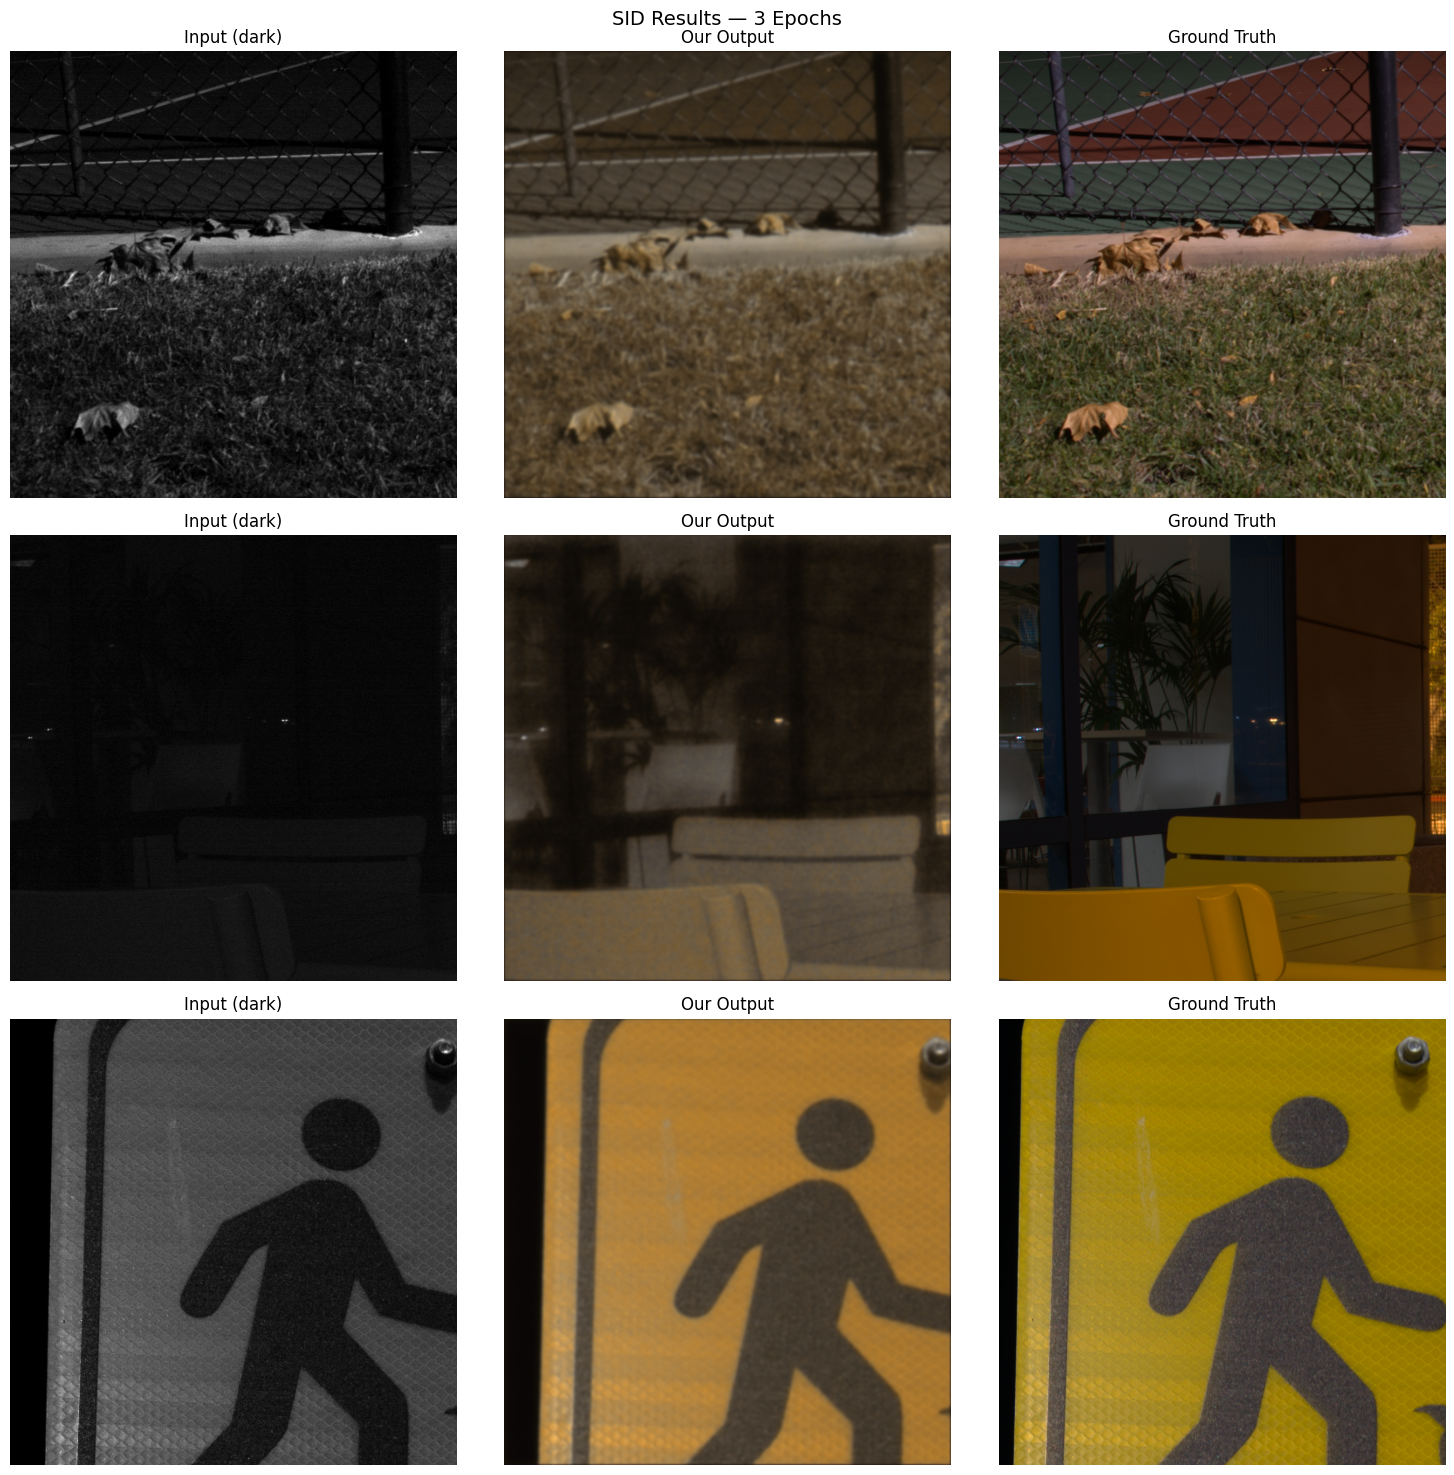

Saved visual_results.png


In [21]:
BASE = '/kaggle/input/datasets/moodoki/sid-sony'

def visualize(model, n=3):
    ds = SIDDataset(
        txt_file  = f'{BASE}/Sony_test_list.txt',
        input_dir = f'{BASE}/Sony/short',
        gt_dir    = f'{BASE}/Sony/long',
        patch_size= 512,
        augment   = False
    )
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    idxs = np.random.choice(len(ds), n, replace=False)
    model.eval()
    for row, idx in enumerate(idxs):
        short, gt = ds[idx]
        with torch.no_grad():
            out = model(short.unsqueeze(0).to(device))
        inp_vis = short.numpy().mean(0)
        out_vis = np.clip(out[0].cpu().numpy().transpose(1,2,0), 0, 1)
        gt_vis  = np.clip(gt.numpy().transpose(1,2,0), 0, 1)
        axes[row,0].imshow(inp_vis, cmap='gray')
        axes[row,0].set_title('Input (dark)'); axes[row,0].axis('off')
        axes[row,1].imshow(out_vis)
        axes[row,1].set_title('Our Output');   axes[row,1].axis('off')
        axes[row,2].imshow(gt_vis)
        axes[row,2].set_title('Ground Truth'); axes[row,2].axis('off')
    plt.suptitle('SID Results — 3 Epochs', fontsize=14)
    plt.tight_layout()
    plt.savefig('visual_results.png', dpi=150)
    plt.show()
    print("Saved visual_results.png")

visualize(model)